In [32]:
import numpy as np 
import h5py 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import time 

file = h5py.File('C:/Users/user/Downloads/sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

print(len(file['snr']))

down_sample = 1000

features = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'ra', 'dec', 'iota', 'psi', 'z']
snr = file['snr'][:down_sample]

X = np.column_stack([file[f][:down_sample] for f in features])

print(X.shape)
print(snr)



20000000
(1000, 13)
[8.22509488e-01 1.09323729e+00 1.30539835e+00 9.11297432e+00
 1.75255341e+01 1.89363162e+00 5.76987829e+00 2.02100692e+01
 1.31471852e+00 4.60504322e+01 1.16915195e+01 5.81113934e-01
 9.44529330e-01 3.08761569e+01 1.39792792e+01 6.93286425e-01
 1.60192476e+01 1.62247284e+01 1.40816483e+00 6.39631138e+00
 1.33181856e+00 3.39078254e-01 1.02497822e+01 1.77462188e+00
 7.27120347e-01 1.49637400e+00 2.67600004e+00 6.76385074e+00
 3.50873182e+00 3.84677717e-01 1.40174407e+00 6.51207160e+00
 6.54829091e+00 8.69885109e+00 5.38779544e+01 4.48730045e+00
 1.73861870e+00 6.21683915e+01 1.65065934e+00 2.41148659e+01
 2.97894683e+01 8.51629190e+00 2.00920998e+00 1.56225712e+00
 3.99651670e-01 6.01124785e+00 1.25651285e+00 6.24985349e+00
 5.09237511e+00 1.16506182e+00 9.73888760e-01 1.75423638e+01
 2.69992581e+01 1.20296248e+00 1.02159276e+02 1.11614141e+01
 1.21397789e+00 5.81995354e-01 2.54032371e+01 3.87256713e-01
 3.07922912e+00 4.00097396e+00 1.83508571e+00 1.07575299e+01
 2.4

In [33]:
from sklearn.model_selection import train_test_split

y = (snr > 12).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [38]:
rf = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

# Generate predictions for the test set
y_pred_test = rf.predict(X_test_scaled)
rms_test = np.sqrt(np.mean((y_pred_test - y_test)**2))

# Generate predictions for the training set
y_pred_train = rf.predict(X_train_scaled)
rms_train = np.sqrt(np.mean((y_pred_train - y_train)**2))

print(f"Test RMS: {rms_test:.3f}")
print(f"Train RMS: {rms_train:.3f}")



Test RMS: 0.687
Train RMS: 0.678


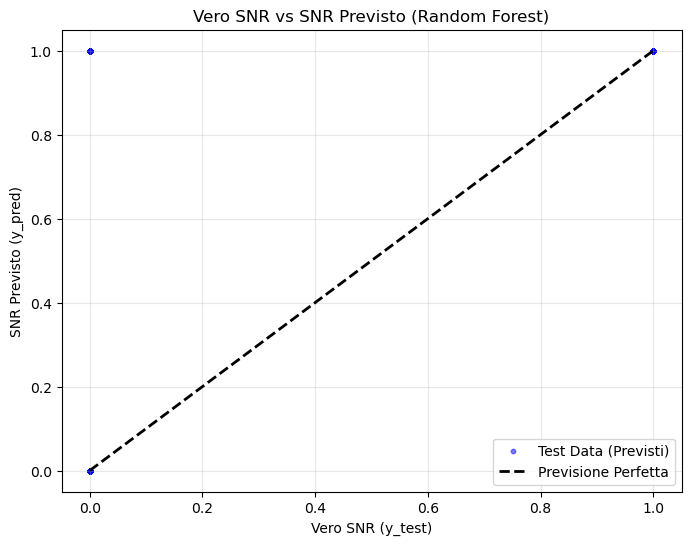

In [39]:
y_pred_test = rf.predict(X_test_scaled)
y_pred_train = rf.predict(X_train_scaled)
plt.figure(figsize=(8, 6))
# Plottiamo i dati di Test
plt.scatter(y_test, y_pred_test, alpha=0.5, label='Test Data (Previsti)', color='blue', s=10)
# Plottiamo una linea diagonale nera per indicare la previsione "perfetta"
max_val = max(np.max(y_test), np.max(y_pred_test))
min_val = min(np.min(y_test), np.min(y_pred_test))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Previsione Perfetta')
plt.xlabel('Vero SNR (y_test)')
plt.ylabel('SNR Previsto (y_pred)')
plt.title('Vero SNR vs SNR Previsto (Random Forest)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()